In [15]:
%load_ext autoreload
%autoreload 2
import numpy as np
from scipy import optimize
import sympy as sm
from types import SimpleNamespace
import time
import matplotlib.pyplot as plt
from IPython.display import display, Math

# plotting
import matplotlib.pyplot as plt
plt.rcParams.update({"axes.grid":True,"grid.color":"black","grid.alpha":"0.25","grid.linestyle":"--"})
plt.rcParams.update({'font.size': 14})

# models
from OLGModel_test import OLGModelClass
import OLGModel_test as olg

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [16]:
model = OLGModelClass()
par = model.par # SimpeNamespace
sim = model.sim # SimpeNamespace

# d. initial values
K_ss = ((1-par.alpha)/((1+1.0/par.beta)))**(1.0/(1-par.alpha))
par.K_lag_ini = 0.1*K_ss
print(K_ss)

initializing the model:
calling .setup()
calling .allocate()
0.221586390489135


In [17]:
from OLGModel_test import simulate_before_s, simulate_after_s, find_s_bracket, calc_euler_error

In [18]:
olg.OLG_analytical(print_output=True)

In [19]:
s_guess = 0.1

In [20]:
# a. initialize
sim.K_lag[0] = par.K_lag_ini

simulate_before_s(par,sim,t=0)
print(f'{sim.C2[0] = : .4f}')

simulate_after_s(par,sim,s=s_guess,t=0)
print(f'{sim.C1[0] = : .4f}')

simulate_before_s(par,sim,t=1)
print(f'{sim.C2[1] = : .4f}')
print(f'{sim.r[1] = : .4f}')

LHS_Euler = sim.C1[0]**(-par.sigma)
RHS_Euler = (1+sim.r[1])*par.beta * sim.C2[1]**(-par.sigma)
print(f'euler-error = {LHS_Euler-RHS_Euler:.8f}')

print(sim.K_lag[4])

sim.C2[0] =  0.1225
sim.C1[0] =  0.1504
sim.C2[1] =  0.1481
sim.r[1] =  3.3020
euler-error = -149.85199192
nan


In [21]:
euler_error = calc_euler_error(s_guess,par,sim,t=0)
print(f'euler-error = {euler_error:.8f}')

euler-error = -149.85199192


In [22]:
s_min,s_max = find_s_bracket(par,sim,t=0,do_print=True);

euler-error for s =   0.99999999 = 358256779379076864.00000000
euler-error for s =   0.50000000 = 103.79607284
euler-error for s =   0.25000001 = -23.83481805
bracket to search in with opposite signed errors:
[  0.25000001-  0.50000000]


In [23]:
obj = lambda s: calc_euler_error(s,par,sim,t=0)
result = optimize.root_scalar(obj,bracket=(s_min,s_max),method='bisect')
print(result)

      converged: True
           flag: converged
 function_calls: 39
     iterations: 37
           root: 0.29778579764819135


In [24]:
euler_error = calc_euler_error(result.root,par,sim,t=0)
print(f'euler-error = {euler_error:.8f}')

euler-error = -0.00000000


In [25]:
model.simulate()

simulation done in 0.01 secs


In [26]:
for t in range(5):
    LHS_Euler = sim.C1[t]**(-par.sigma)
    RHS_Euler = (1+sim.r[t+1])*par.beta * sim.C2[t+1]**(-par.sigma)
    print(f't = {t:2d}: euler-error = {LHS_Euler-RHS_Euler:.8f}')

t =  0: euler-error = -0.00000000
t =  1: euler-error = -0.00000000
t =  2: euler-error = 0.00000000
t =  3: euler-error = 0.00000000
t =  4: euler-error = 0.00000000


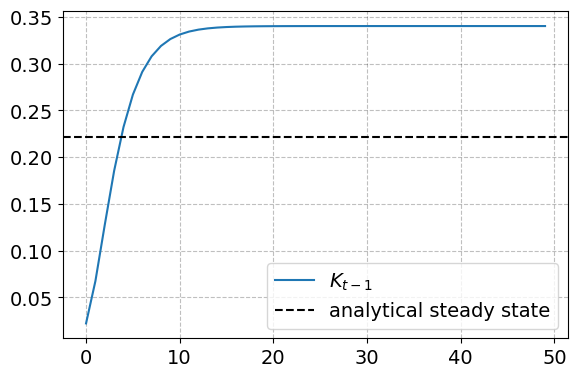

In [27]:
fig = plt.figure(figsize=(6,6/1.5))
ax = fig.add_subplot(1,1,1)
ax.plot(model.sim.K_lag,label=r'$K_{t-1}$')
ax.axhline(K_ss,ls='--',color='black',label='analytical steady state')
ax.legend(frameon=True)
fig.tight_layout()
K_lag_old = model.sim.K_lag.copy() #saves result for comparison later

In [28]:
print(s)

NameError: name 's' is not defined